In [50]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [51]:
df = pd.read_csv('1553768847-housing.csv')
df.head() 

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200


In [52]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

In [53]:
# sns.scatterplot(x=df['']) 
df['ocean_proximity'].unique() 

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [54]:
df = pd.get_dummies(df,columns=['ocean_proximity'],drop_first=True,dtype=float)

In [55]:
y = df['median_house_value']
x = df.drop(columns=['median_house_value'],axis=1)

In [56]:
x.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN'],
      dtype='object')

In [57]:
from sklearn.model_selection import train_test_split 
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [58]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()

In [59]:
# x_train.loc[:,~([ 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       # 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN'])]
x.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41,880,129.0,322,126,8.3252,0.0,0.0,1.0,0.0
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,0.0,0.0,1.0,0.0
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,0.0,0.0,1.0,0.0
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,0.0,0.0,1.0,0.0
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,0.0,0.0,1.0,0.0


In [60]:
x_train.iloc[:,:8] = scaler.fit_transform(x_train.iloc[:,:8])

C:\Users\susha\AppData\Local\Temp\ipykernel_16696\682842795.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.50935748 -0.67987313 -0.36274497 ...  0.58863952 -1.07628333
  1.85715216]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  x_train.iloc[:,:8] = scaler.fit_transform(x_train.iloc[:,:8])
C:\Users\susha\AppData\Local\Temp\ipykernel_16696\682842795.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.11324158 -0.21356615 -0.48263943 ... -0.25147682  0.42999055
  0.73096426]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  x_train.iloc[:,:8] = scaler.fit_transform(x_train.iloc[:,:8])
C:\Users\susha\AppData\Local\Temp\ipykernel_16696\682842795.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of p

In [61]:
x_test.iloc[:,:8] = scaler.transform(x_test.iloc[:,:8])

C:\Users\susha\AppData\Local\Temp\ipykernel_16696\3258189430.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.28346293  0.11294728  1.85715216 ... -0.99700129 -1.47269353
 -0.91771925]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  x_test.iloc[:,:8] = scaler.transform(x_test.iloc[:,:8])
C:\Users\susha\AppData\Local\Temp\ipykernel_16696\3258189430.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.52702265  0.13780101  0.54788348 ...  2.45774895  3.03288151
  1.21917969]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  x_test.iloc[:,:8] = scaler.transform(x_test.iloc[:,:8])
C:\Users\susha\AppData\Local\Temp\ipykernel_16696\3258189430.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Va

In [62]:
from sklearn.linear_model import LinearRegression 
lr = LinearRegression()

In [63]:
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [64]:
y_pred = lr.predict(x_test)

In [65]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print(r2)

0.6393611711434393


In [66]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]

df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]

df["population_per_household"] = df["population"] / df["households"]

In [67]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,0.0,0.0,1.0,0.0,6.984127,0.146591,2.555556
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,0.0,0.0,1.0,0.0,6.238137,0.155797,2.109842
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,0.0,0.0,1.0,0.0,8.288136,0.129516,2.802260
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,0.0,0.0,1.0,0.0,5.817352,0.184458,2.547945
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,0.0,0.0,1.0,0.0,6.281853,0.172096,2.181467


In [68]:
cols = ['rooms_per_household','bedrooms_per_room','population_per_household']

In [69]:
x = pd.concat([x,df[cols]],axis=1)

In [70]:
x.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41,880,129.0,322,126,8.3252,0.0,0.0,1.0,0.0,6.984127,0.146591,2.555556
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,0.0,0.0,1.0,0.0,6.238137,0.155797,2.109842
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,0.0,0.0,1.0,0.0,8.288136,0.129516,2.802260
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,0.0,0.0,1.0,0.0,5.817352,0.184458,2.547945
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,0.0,0.0,1.0,0.0,6.281853,0.172096,2.181467


<Axes: >

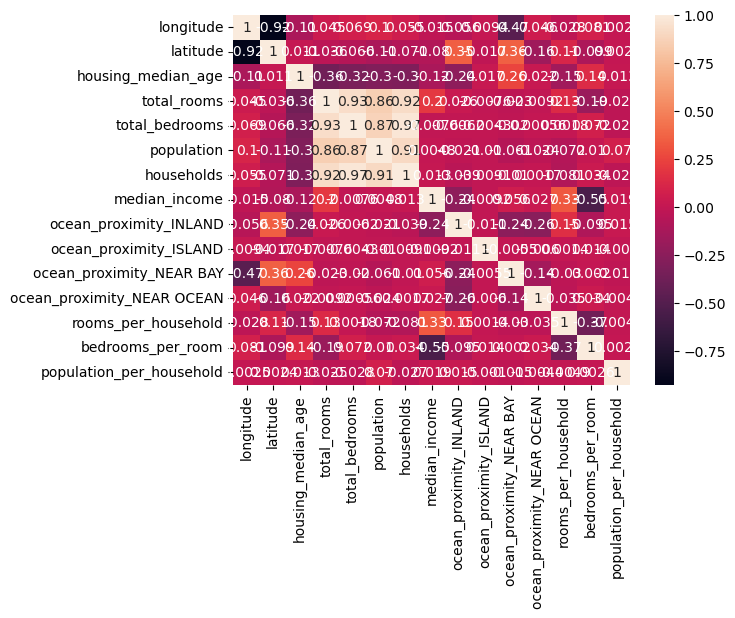

In [71]:
sns.heatmap(x.corr(),annot=True)

In [72]:
x_train2 , x_test2 , y_train2 , y_test2 = train_test_split(x,y,test_size=0.3,random_state=42)

In [73]:
col_2 = [0,1,2,3,4,5,6,7,12,13,14]

In [74]:
x_train2.iloc[:,col_2] = scaler.fit_transform(x_train2.iloc[:,col_2])

C:\Users\susha\AppData\Local\Temp\ipykernel_16696\1466192534.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.50935748 -0.67987313 -0.36274497 ...  0.58863952 -1.07628333
  1.85715216]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  x_train2.iloc[:,col_2] = scaler.fit_transform(x_train2.iloc[:,col_2])
C:\Users\susha\AppData\Local\Temp\ipykernel_16696\1466192534.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.11324158 -0.21356615 -0.48263943 ... -0.25147682  0.42999055
  0.73096426]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  x_train2.iloc[:,col_2] = scaler.fit_transform(x_train2.iloc[:,col_2])
C:\Users\susha\AppData\Local\Temp\ipykernel_16696\1466192534.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in 

In [75]:
x_test2.iloc[:,col_2] = scaler.transform(x_test2.iloc[:,col_2])

C:\Users\susha\AppData\Local\Temp\ipykernel_16696\2148532387.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.28346293  0.11294728  1.85715216 ... -0.99700129 -1.47269353
 -0.91771925]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  x_test2.iloc[:,col_2] = scaler.transform(x_test2.iloc[:,col_2])
C:\Users\susha\AppData\Local\Temp\ipykernel_16696\2148532387.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.52702265  0.13780101  0.54788348 ...  2.45774895  3.03288151
  1.21917969]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  x_test2.iloc[:,col_2] = scaler.transform(x_test2.iloc[:,col_2])
C:\Users\susha\AppData\Local\Temp\ipykernel_16696\2148532387.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future err

In [76]:
lr2 = LinearRegression()
lr2.fit(x_train2,y_train2)
y_pred2 = lr2.predict(x_test2)

In [77]:
r2_2 = r2_score(y_test2, y_pred2)
print(r2_2)

0.6220014471923554


In [78]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
print("R2 Score:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAPE:", mape*100, "%")

R2 Score: 0.6393611711434393
MAE: 50078.09884156545
MSE: 4733529273.092555
RMSE: 68800.64878395083
MAPE: 28.951552297380378 %
